In [1]:
# ==========================
# Import Libraries
# ==========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("../dataset/hdi_dataset.csv", encoding="latin1")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display first 5 rows
df.head()

,HDI rank,Country,HUMAN DEVELOPMENT,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank.1,Unnamed: 10,Unnamed: 11
0,1,Switzerland,VERY HIGH,0.962,84.0,16.5,13.9,"66,933",5,3,NaN,NaN
1,2,Norway,VERY HIGH,0.961,83.2,18.2,13.0,"64,660",6,1,NaN,NaN
2,3,Iceland,VERY HIGH,0.959,82.7,19.2,13.8,"55,782",11,2,NaN,NaN
3,4,"Hong Kong, China (SAR)",VERY HIGH,0.952,85.5,17.3,12.2,"62,607",6,4,NaN,NaN
4,5,Australia,VERY HIGH,0.951,84.5,21.1,12.7,"49,238",18,5,NaN,NaN


In [2]:
# Dataset Shape

print("Rows and Columns:", df.shape)

Rows and Columns: (195, 12)


In [3]:
# Column Names

print(df.columns)

Index(['HDI rank', 'Country', 'HUMAN DEVELOPMENT',
       'Human Development Index (HDI)', 'Life expectancy at birth',
       'Expected years of schooling', 'Mean years of schooling',
       'Gross national income (GNI) per capita',
       'GNI per capita rank minus HDI rank', 'HDI rank.1', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')


In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   HDI rank                                195 non-null    int64  
 1   Country                                 195 non-null    object 
 2   HUMAN DEVELOPMENT                       195 non-null    object 
 3   Human Development Index (HDI)           195 non-null    object 
 4   Life expectancy at birth                195 non-null    float64
 5   Expected years of schooling             195 non-null    object 
 6   Mean years of schooling                 195 non-null    object 
 7   Gross national income (GNI) per capita  195 non-null    object 
 8   GNI per capita rank minus HDI rank      195 non-null    object 
 9   HDI rank.1                              195 non-null    object 
 10  Unnamed: 10                             0 non-null      float6

In [5]:
# Statistical Summary

df.describe()

,HDI rank,Life expectancy at birth,Unnamed: 10,Unnamed: 11
count,195.000000,195.000000,0.0,0.0
mean,97.815385,71.277949,NaN,NaN
std,56.467551,7.746484,NaN,NaN
min,1.000000,52.500000,NaN,NaN
25%,49.500000,65.700000,NaN,NaN
50%,97.000000,71.700000,NaN,NaN
75%,146.000000,76.700000,NaN,NaN
max,195.000000,85.900000,NaN,NaN


In [6]:
# Missing Values

df.isnull().sum()

HDI rank                                    0
Country                                     0
HUMAN DEVELOPMENT                           0
Human Development Index (HDI)               0
Life expectancy at birth                    0
Expected years of schooling                 0
Mean years of schooling                     0
Gross national income (GNI) per capita      0
GNI per capita rank minus HDI rank          0
HDI rank.1                                  0
Unnamed: 10                               195
Unnamed: 11                               195
dtype: int64

In [7]:
# Duplicate Values

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
# Remove Unnecessary Columns

df = df.drop(columns=[
    "Unnamed: 10",
    "Unnamed: 11",
    "HUMAN DEVELOPMENT"
], errors="ignore")

df.head()

,HDI rank,Country,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank.1
0,1,Switzerland,0.962,84.0,16.5,13.9,"66,933",5,3
1,2,Norway,0.961,83.2,18.2,13.0,"64,660",6,1
2,3,Iceland,0.959,82.7,19.2,13.8,"55,782",11,2
3,4,"Hong Kong, China (SAR)",0.952,85.5,17.3,12.2,"62,607",6,4
4,5,Australia,0.951,84.5,21.1,12.7,"49,238",18,5


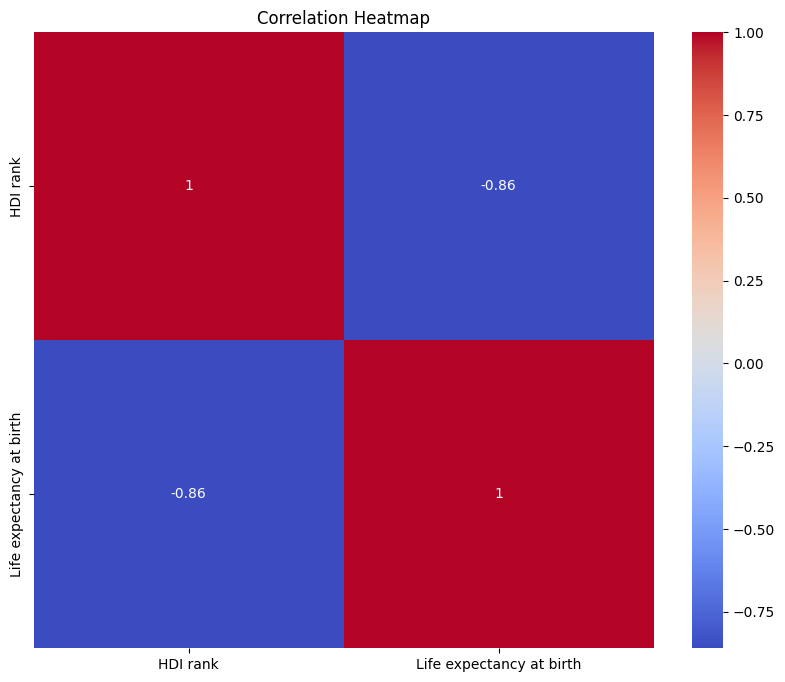

In [9]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

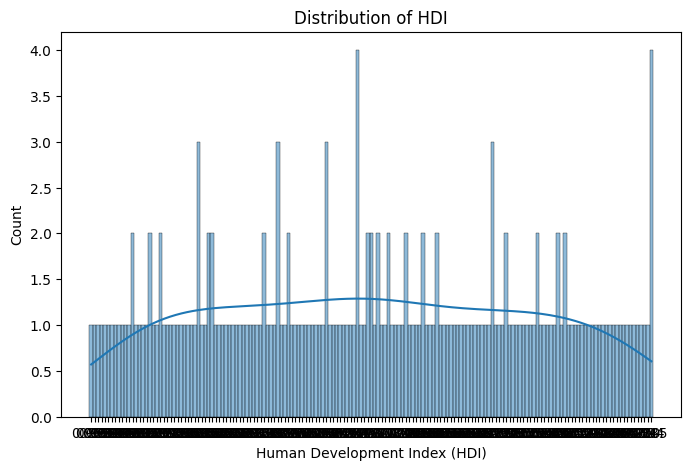

In [10]:
# Distribution of HDI

plt.figure(figsize=(8,5))

sns.histplot(df["Human Development Index (HDI)"], kde=True)

plt.title("Distribution of HDI")

plt.show()

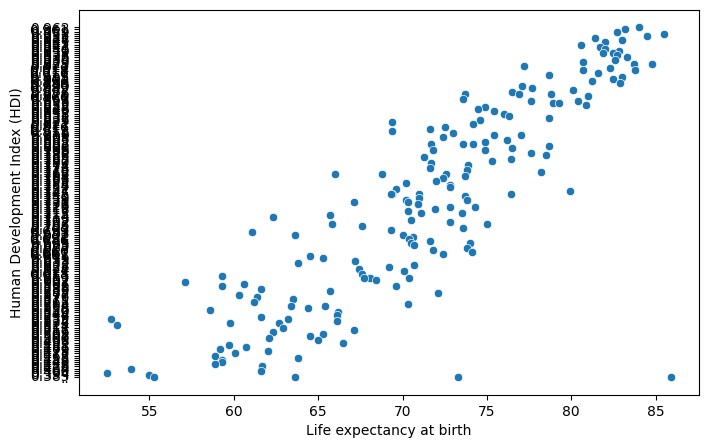

In [11]:
# Life Expectancy vs HDI

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Life expectancy at birth",
    y="Human Development Index (HDI)",
    data=df
)

plt.show()

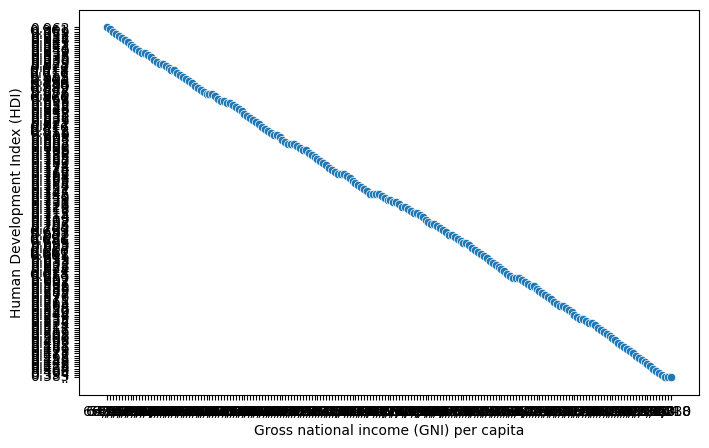

In [12]:
# GNI vs HDI

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Gross national income (GNI) per capita",
    y="Human Development Index (HDI)",
    data=df
)

plt.show()

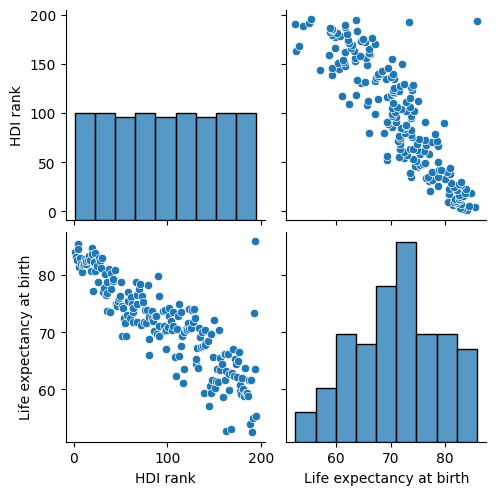

In [13]:
# Pairplot

sns.pairplot(df.select_dtypes(include=np.number))

plt.show()

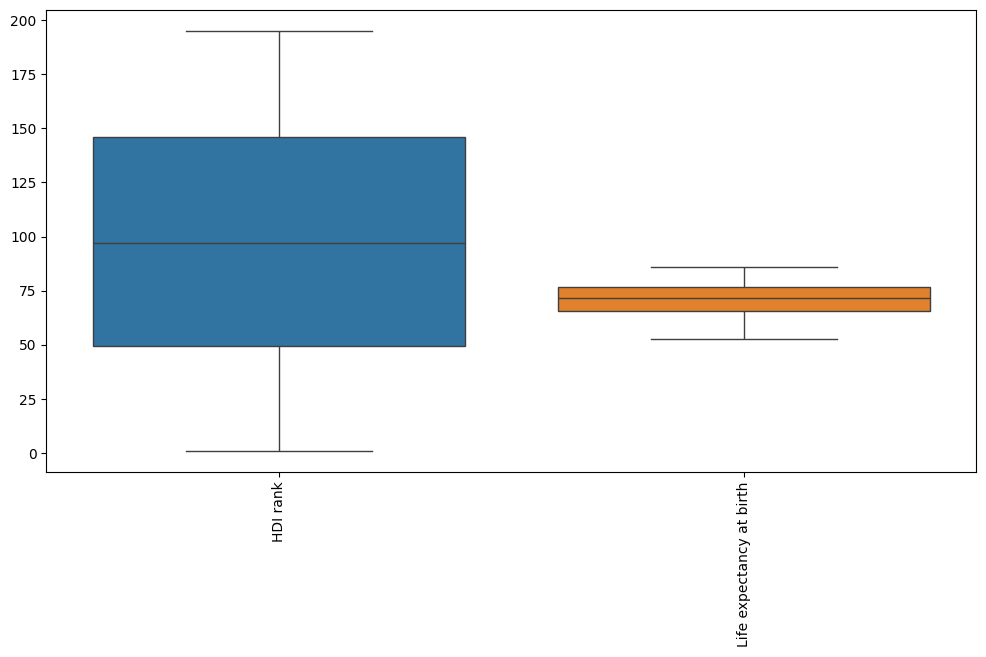

In [14]:
# Boxplot

plt.figure(figsize=(12,6))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.show()